In [54]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

In [92]:
df = pd.read_excel("2024-yili-arama-kurtarma.xlsx")


In [56]:
df.head()

,TARIH,KURTARMA_TURU,CIKIS_SAATI,VARIS_SURESI,MAHALLE,ILCE,ERKEK_VEFAT,KADIN_VEFAT,ITFAIYECI_VEFAT,ERKEK_YARALI,KADIN_YARALI,ITFAIYECI_YARALI,BUYUK_BAS_VEFAT,KUCUK_BAS_VEFAT,KUMES_HAYVANI_VEFAT,EVCIL_HAYVAN_VEFAT,DIGER,ADRES_BOLGESI
0,1.01.2024,112 ACİL SAĞLIK/AMBULANS,00:41,00:04,GÜNEY,KONAK,0,0,0,0,0,0,0,0,0,0,0,KENT MERKEZİ
1,1.01.2024,112 ACİL SAĞLIK/AMBULANS,00:50,NaN,GÜMÜŞPALA,BAYRAKLI,0,0,0,1,0,0,0,0,0,0,0,KENT MERKEZİ
2,1.01.2024,TRAFİK KAZASI,01:26,00:04,KURUÇEŞME,BUCA,0,0,0,0,0,0,0,0,0,0,0,KENT MERKEZİ
3,1.01.2024,112 ACİL SAĞLIK/AMBULANS,01:58,00:07,BOSTANLI,KARŞIYAKA,0,0,0,0,0,0,0,0,0,0,0,KENT MERKEZİ
4,1.01.2024,YÜZÜK KESME,02:42,00:03,KAZIMDİRİK,BORNOVA,0,0,0,1,0,0,0,0,0,0,0,KENT MERKEZİ


## sadece ilgilendiğimiz sütunları sadeleştiriyoruz.

In [57]:
df = df[["TARIH", "KURTARMA_TURU", "CIKIS_SAATI", "VARIS_SURESI", "MAHALLE", "ILCE",  "ERKEK_VEFAT", "KADIN_VEFAT",  "ERKEK_YARALI", "KADIN_YARALI"]].copy()

In [58]:
df.head()

,TARIH,KURTARMA_TURU,CIKIS_SAATI,VARIS_SURESI,MAHALLE,ILCE,ERKEK_VEFAT,KADIN_VEFAT,ERKEK_YARALI,KADIN_YARALI
0,1.01.2024,112 ACİL SAĞLIK/AMBULANS,00:41,00:04,GÜNEY,KONAK,0,0,0,0
1,1.01.2024,112 ACİL SAĞLIK/AMBULANS,00:50,NaN,GÜMÜŞPALA,BAYRAKLI,0,0,1,0
2,1.01.2024,TRAFİK KAZASI,01:26,00:04,KURUÇEŞME,BUCA,0,0,0,0
3,1.01.2024,112 ACİL SAĞLIK/AMBULANS,01:58,00:07,BOSTANLI,KARŞIYAKA,0,0,0,0
4,1.01.2024,YÜZÜK KESME,02:42,00:03,KAZIMDİRİK,BORNOVA,0,0,1,0


In [59]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 12828 entries, 0 to 12827
Data columns (total 10 columns):
 #   Column         Non-Null Count  Dtype 
---  ------         --------------  ----- 
 0   TARIH          12828 non-null  object
 1   KURTARMA_TURU  12828 non-null  object
 2   CIKIS_SAATI    12828 non-null  object
 3   VARIS_SURESI   12760 non-null  object
 4   MAHALLE        12803 non-null  object
 5   ILCE           12828 non-null  object
 6   ERKEK_VEFAT    12828 non-null  int64 
 7   KADIN_VEFAT    12828 non-null  int64 
 8   ERKEK_YARALI   12828 non-null  int64 
 9   KADIN_YARALI   12828 non-null  int64 
dtypes: int64(4), object(6)
memory usage: 1002.3+ KB


In [60]:
df.isnull().sum()

TARIH             0
KURTARMA_TURU     0
CIKIS_SAATI       0
VARIS_SURESI     68
MAHALLE          25
ILCE              0
ERKEK_VEFAT       0
KADIN_VEFAT       0
ERKEK_YARALI      0
KADIN_YARALI      0
dtype: int64

## varış süresi ve mahalle bilgisi olmayan satırları sadeleştiriyoruz.

In [61]:
df.dropna(subset=["VARIS_SURESI", "MAHALLE"], inplace=True)
df.isnull().sum()

TARIH            0
KURTARMA_TURU    0
CIKIS_SAATI      0
VARIS_SURESI     0
MAHALLE          0
ILCE             0
ERKEK_VEFAT      0
KADIN_VEFAT      0
ERKEK_YARALI     0
KADIN_YARALI     0
dtype: int64

In [62]:
df["ILCE"].unique()

array(['KONAK', 'BUCA', 'KARŞIYAKA', 'BORNOVA', 'GAZİEMİR', 'KARABAĞLAR',
       'BALÇOVA', 'URLA', 'SEFERİHİSAR', 'ÇİĞLİ', 'FOÇA', 'KİRAZ',
       'ÇEŞME', 'ALİAĞA', 'SELÇUK', 'ÖDEMİŞ', 'TORBALI', 'DİKİLİ',
       'BAYRAKLI', 'GÜZELBAHÇE', 'NARLIDERE', 'MENDERES', 'MENEMEN',
       'KARABURUN', 'BERGAMA', 'KEMALPAŞA', 'TİRE', 'KINIK', 'BAYINDIR',
       'İL DIŞI', 'BEYDAĞ'], dtype=object)

In [63]:
# il dışı parametresini kaldırmalıyız.
df = df[df['ILCE'] != 'İL DIŞI']

In [64]:
df["ILCE"].unique()

array(['KONAK', 'BUCA', 'KARŞIYAKA', 'BORNOVA', 'GAZİEMİR', 'KARABAĞLAR',
       'BALÇOVA', 'URLA', 'SEFERİHİSAR', 'ÇİĞLİ', 'FOÇA', 'KİRAZ',
       'ÇEŞME', 'ALİAĞA', 'SELÇUK', 'ÖDEMİŞ', 'TORBALI', 'DİKİLİ',
       'BAYRAKLI', 'GÜZELBAHÇE', 'NARLIDERE', 'MENDERES', 'MENEMEN',
       'KARABURUN', 'BERGAMA', 'KEMALPAŞA', 'TİRE', 'KINIK', 'BAYINDIR',
       'BEYDAĞ'], dtype=object)

## toplam varış süresini saat:dakika cinsinden dakika cinsine çevirip tabloya ekleyeceğiz.

In [65]:
def sureyi_hesapla(x):
    # Eğer veri string değilse veya boşsa (NaN) doğrudan 0 veya None döndür
    if not isinstance(x, str) or ":" not in str(x):
        return 0 
    
    parcalar = x.split(':')
    # HH:MM formatını dakikaya çeviriyoruz
    return int(parcalar[0]) * 60 + int(parcalar[1])

In [66]:
df["TOPLAM_VARIS_SURESI"] = df["VARIS_SURESI"].apply(sureyi_hesapla)
df = df[df['TOPLAM_VARIS_SURESI'] > 0]

In [67]:
df.describe()

,ERKEK_VEFAT,KADIN_VEFAT,ERKEK_YARALI,KADIN_YARALI,TOPLAM_VARIS_SURESI
count,12730.000000,12730.000000,12730.000000,12730.000000,12730.000000
mean,0.016968,0.006284,0.150589,0.106520,6.412412
std,0.135101,0.088411,0.466686,0.346192,9.650881
min,0.000000,0.000000,0.000000,0.000000,1.000000
25%,0.000000,0.000000,0.000000,0.000000,3.000000
50%,0.000000,0.000000,0.000000,0.000000,5.000000
75%,0.000000,0.000000,0.000000,0.000000,6.000000
max,3.000000,3.000000,11.000000,5.000000,628.000000


## şimdi ilgilendiğimiz trafik kazası verilerini sadeleştirelim

In [68]:
df = df[df["KURTARMA_TURU"] == "TRAFİK KAZASI"]
print(f"Toplam Trafik Kazası Sayısı: {len(df)}")

Toplam Trafik Kazası Sayısı: 1118


In [69]:
df.describe()

,ERKEK_VEFAT,KADIN_VEFAT,ERKEK_YARALI,KADIN_YARALI,TOPLAM_VARIS_SURESI
count,1118.000000,1118.000000,1118.000000,1118.000000,1118.000000
mean,0.050089,0.014311,0.699463,0.312165,6.157424
std,0.255985,0.145881,0.981028,0.673088,5.189023
min,0.000000,0.000000,0.000000,0.000000,1.000000
25%,0.000000,0.000000,0.000000,0.000000,3.000000
50%,0.000000,0.000000,0.000000,0.000000,5.000000
75%,0.000000,0.000000,1.000000,0.000000,7.000000
max,3.000000,3.000000,9.000000,5.000000,80.000000


Yani trafik kazaları, müdahale süresi açısından asansörde kalma veya kapı açma gibi diğer vakalara göre çok daha tutarlı bir karakter sergiliyor.

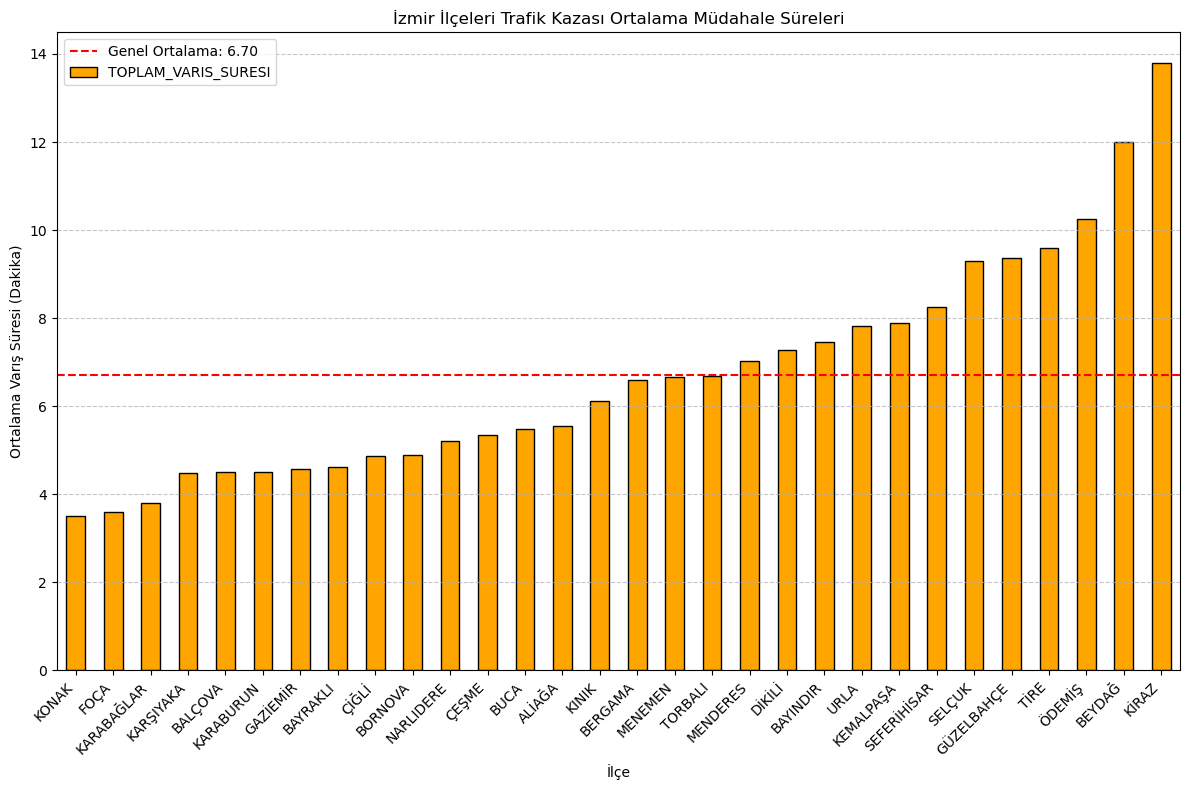

In [70]:
ilce_trafik_analiz = df.groupby('ILCE')['TOPLAM_VARIS_SURESI'].mean().sort_values()

# Grafik oluşturma
plt.figure(figsize=(12, 8))
ilce_trafik_analiz.plot(kind='bar', color='orange', edgecolor='black')

# Başlık ve etiketler
plt.title('İzmir İlçeleri Trafik Kazası Ortalama Müdahale Süreleri')
plt.xlabel('İlçe')
plt.ylabel('Ortalama Varış Süresi (Dakika)')
plt.xticks(rotation=45, ha='right')
plt.grid(axis='y', linestyle='--', alpha=0.7)

# Ortalama çizgisi ekleyelim
plt.axhline(ilce_trafik_analiz.mean(), color='red', linestyle='--', label=f'Genel Ortalama: {ilce_trafik_analiz.mean():.2f}')
plt.legend()

plt.tight_layout()
plt.show()

In [78]:
# 1. İlçe bazlı vaka sayısı ve ortalama süreyi birleştirelim
performans_ozeti = df.groupby('ILCE')['TOPLAM_VARIS_SURESI'].agg(['count', 'mean'])
performans_ozeti.columns = ['Vaka_Sayisi', 'Ortalama_Sure']

# 2. Verimlilik Skorunu hesaplayalım
performans_ozeti['Verimlilik_Skoru'] = performans_ozeti['Vaka_Sayisi'] / performans_ozeti['Ortalama_Sure']

# 3. Başarıyı kanıtlamak için sıralayalım
en_verimli_ilceler = performans_ozeti.sort_values(by='Verimlilik_Skoru', ascending=False)


In [79]:
"""
verimlilik skoru yüksek ilçelerin çoğunlukta İzmir'in en kalabalık ilçelerinden oluşması, 
İzmir İtfaiyesi'nin zorlu trafik koşullarına rağmen olaya en hızlı şekilde müdahale edebildiğini gösteriyor.
"""
en_verimli_ilceler

,Vaka_Sayisi,Ortalama_Sure,Verimlilik_Skoru
ILCE,,,
BORNOVA,102,4.882353,20.891566
KONAK,63,3.507937,17.959276
BUCA,73,5.479452,13.322500
MENEMEN,78,6.666667,11.700000
KARABAĞLAR,44,3.795455,11.592814
TORBALI,74,6.689189,11.062626
KEMALPAŞA,82,7.890244,10.392581
BAYRAKLI,46,4.630435,9.934272
KARŞIYAKA,43,4.488372,9.580311


In [75]:
performans_ozeti.sort_values(by='Vaka_Sayisi', ascending=False)

,Vaka_Sayisi,Ortalama_Sure,Verimlilik_Skoru
ILCE,,,
BORNOVA,102,4.882353,20.891566
KEMALPAŞA,82,7.890244,10.392581
MENEMEN,78,6.666667,11.700000
TORBALI,74,6.689189,11.062626
BUCA,73,5.479452,13.322500
KONAK,63,3.507937,17.959276
MENDERES,59,7.033898,8.387952
BAYRAKLI,46,4.630435,9.934272
BERGAMA,45,6.600000,6.818182


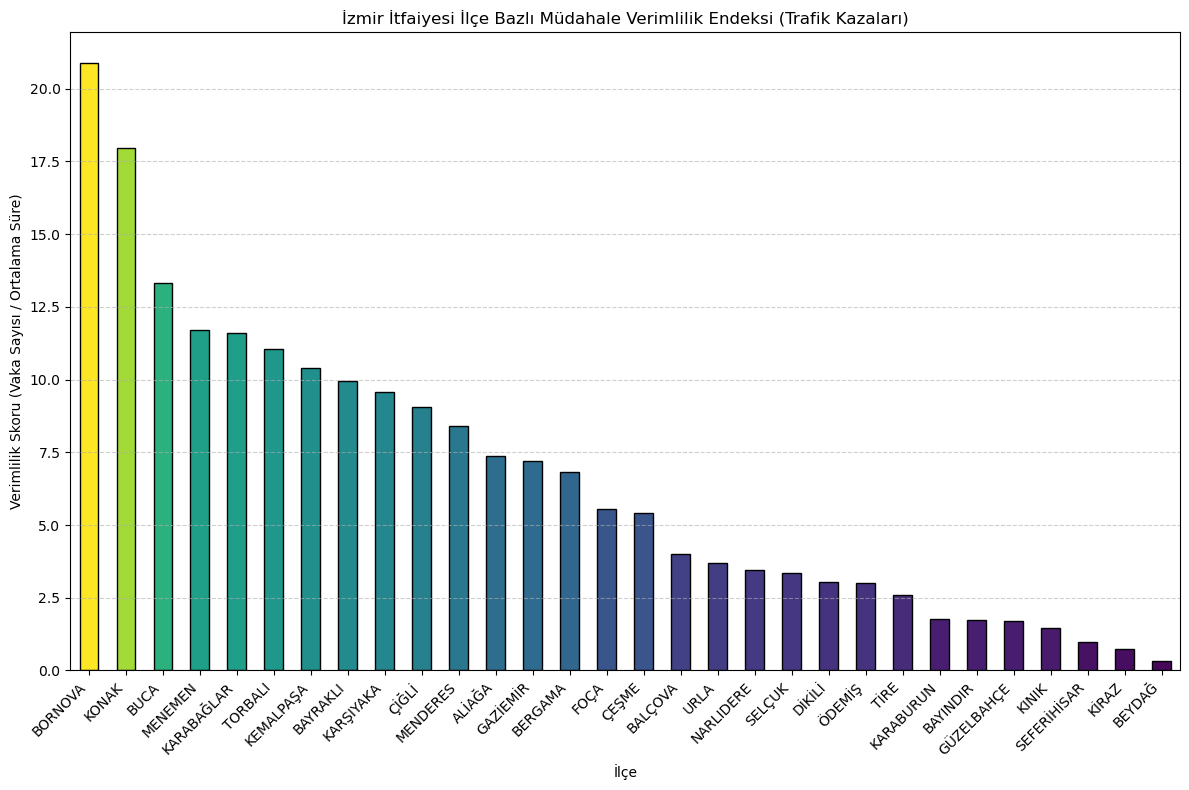

In [81]:
plt.figure(figsize=(12, 8))
colors = plt.cm.viridis(en_verimli_ilceler['Verimlilik_Skoru'] / en_verimli_ilceler['Verimlilik_Skoru'].max())
en_verimli_ilceler['Verimlilik_Skoru'].plot(kind='bar', color=colors, edgecolor='black')

plt.title('İzmir İtfaiyesi İlçe Bazlı Müdahale Verimlilik Endeksi (Trafik Kazaları)')
plt.xlabel('İlçe')
plt.ylabel('Verimlilik Skoru (Vaka Sayısı / Ortalama Süre)')
plt.xticks(rotation=45, ha='right')
plt.grid(axis='y', linestyle='--', alpha=0.6)

plt.tight_layout()
plt.show()

İzmir İtfaiyesi en zorlu kentsel koşullarda bile müdahale hızını optimize edebilir, yani yük arttıkça performansında kayıp olmadığını gösterir.

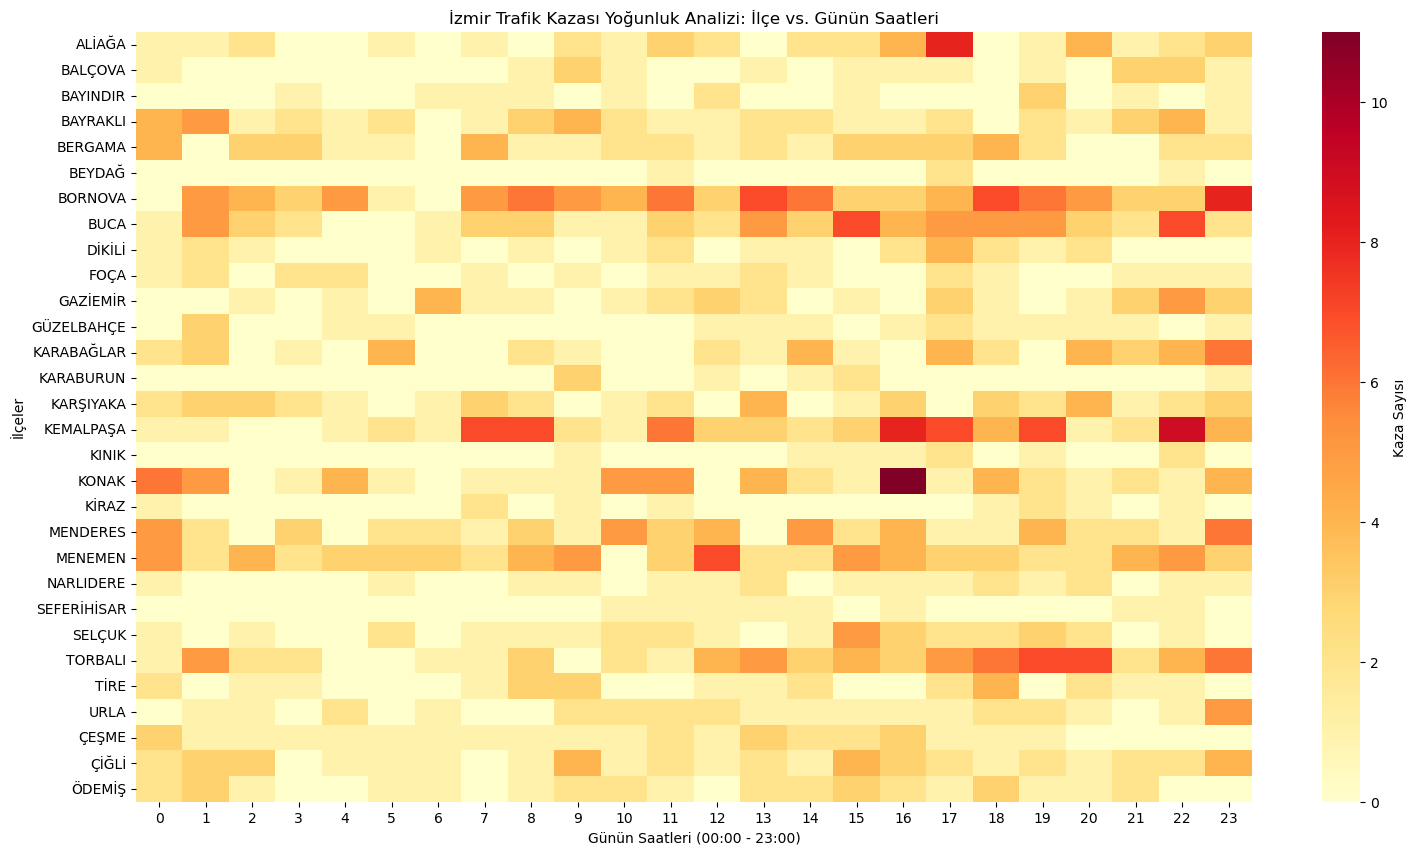

In [85]:
import seaborn as sns
# 1. Saat bilgisini içeren sütundan sadece 'saat' kısmını alalım (Örn: 14:30 -> 14)
# Veri setinde saat sütununun adının 'SAAT' olduğunu varsayıyoruz
df['VAKA_SAATI'] = pd.to_datetime(df['CIKIS_SAATI'], format='%H:%M').dt.hour

# 2. İlçe ve Saat bazlı vaka sayılarını (yoğunluk) pivot tabloya dönüştürelim
yoğunluk_matrisi = df.pivot_table(index='ILCE', 
                                  columns='VAKA_SAATI', 
                                  values='TOPLAM_VARIS_SURESI', 
                                  aggfunc='count').fillna(0)

# 3. Isı Haritasını Çizelim
plt.figure(figsize=(18, 10))
sns.heatmap(yoğunluk_matrisi, cmap="YlOrRd", annot=False, cbar_kws={'label': 'Kaza Sayısı'})

plt.title('İzmir Trafik Kazası Yoğunluk Analizi: İlçe vs. Günün Saatleri')
plt.xlabel('Günün Saatleri (00:00 - 23:00)')
plt.ylabel('İlçeler')
plt.show()

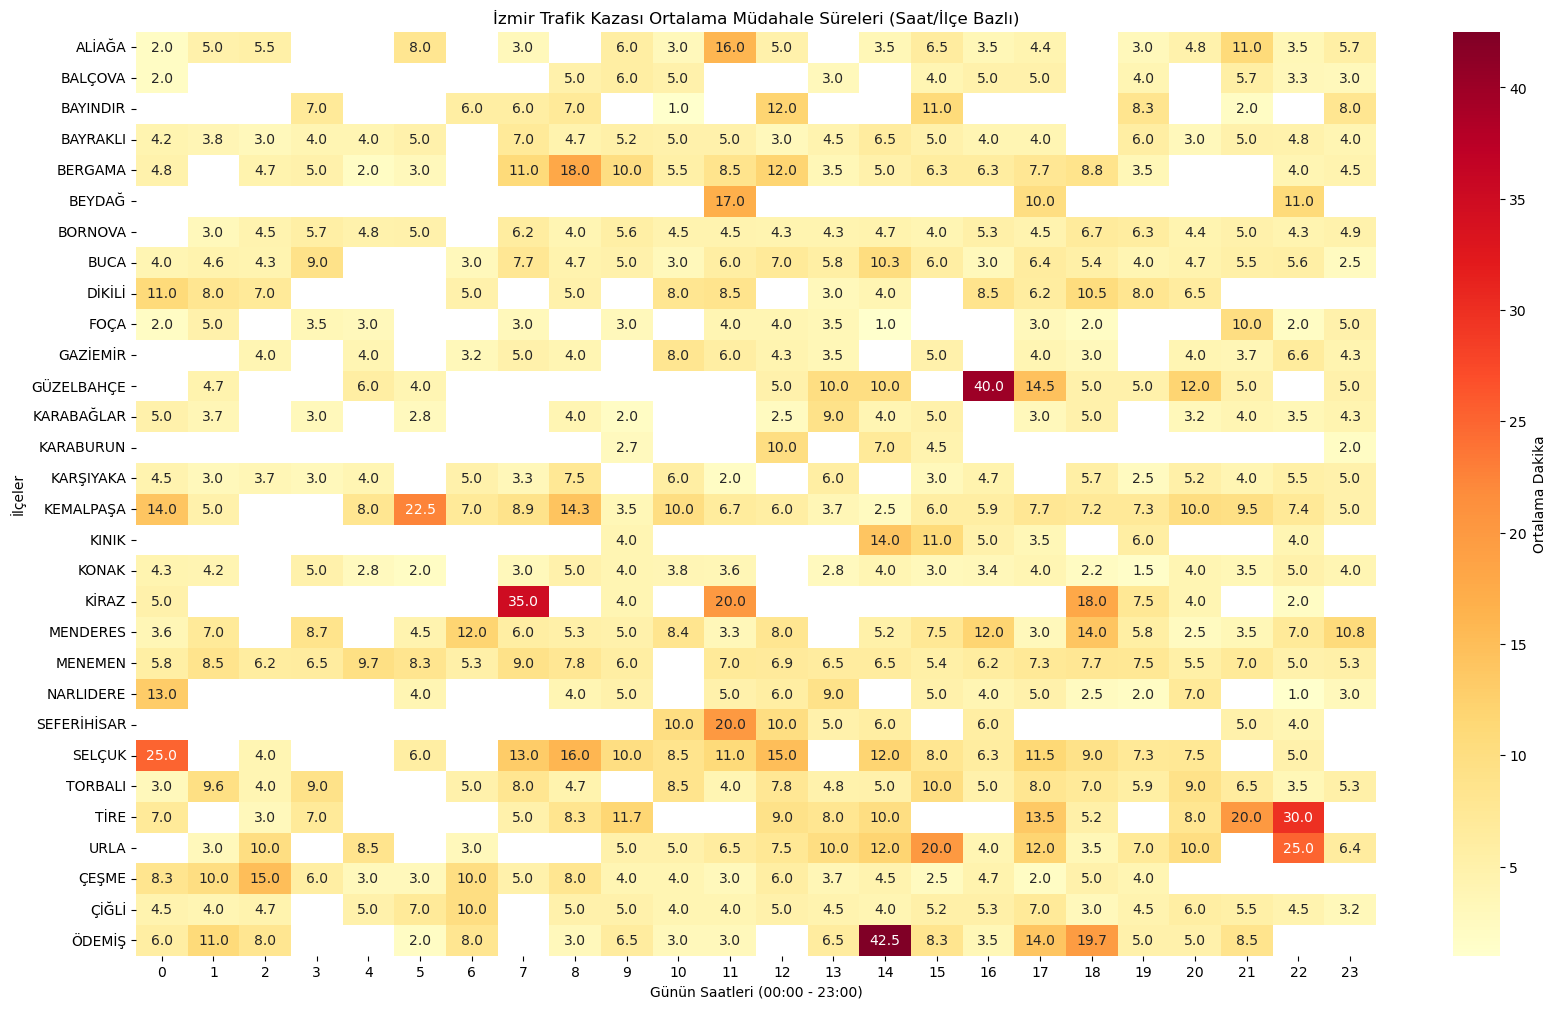

In [86]:
# 1. Saat bilgisini ayıklayalım (Hali hazırda yapmadıysan)
df['VAKA_SAATI'] = pd.to_datetime(df['CIKIS_SAATI'], format='%H:%M').dt.hour

# 2. Ortalama varış süresi için pivot tablo (Değerler: Mean)
sure_matrisi = df.pivot_table(index='ILCE', 
                               columns='VAKA_SAATI', 
                               values='TOPLAM_VARIS_SURESI', 
                               aggfunc='mean')

# 3. Isı Haritasını Çizelim
plt.figure(figsize=(20, 12))
sns.heatmap(sure_matrisi, 
            cmap="YlOrRd", 
            annot=True, 
            fmt=".1f", 
            cbar_kws={'label': 'Ortalama Dakika'})

plt.title('İzmir Trafik Kazası Ortalama Müdahale Süreleri (Saat/İlçe Bazlı)')
plt.xlabel('Günün Saatleri (00:00 - 23:00)')
plt.ylabel('İlçeler')
plt.show()

In [89]:
from sklearn.ensemble import RandomForestRegressor
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_absolute_error
from sklearn.preprocessing import LabelEncoder

# Sadece trafik kazalarını filtreleme
df_trafik = df[df['KURTARMA_TURU'] == 'TRAFİK KAZASI'].copy()

# İlçeleri sayısallaştırma
le = LabelEncoder()
df_trafik['ILCE_KOD'] = le.fit_transform(df_trafik['ILCE'])

# Saat bilgisini numerik bir özelliğe çevirme (0-23 arası saat)
df_trafik['SAAT_KOD'] = pd.to_datetime(df_trafik['CIKIS_SAATI'], format='%H:%M').dt.hour

# Özellikler ve Hedef
X = df_trafik[['ILCE_KOD', 'SAAT_KOD']]
y = df_trafik['TOPLAM_VARIS_SURESI']

# Eğitim ve Test Bölmesi
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Random Forest Modelini Eğitme
rf_final = RandomForestRegressor(n_estimators=200, max_depth=10, random_state=42)
rf_final.fit(X_train, y_train)

# Tahmin ve Hata Hesaplama
y_pred = rf_final.predict(X_test)
final_mae = mean_absolute_error(y_test, y_pred)

print(f"Final Model Ortalama Mutlak Hata (MAE): {final_mae:.2f} Dakika")

Final Model Ortalama Mutlak Hata (MAE): 3.63 Dakika
